<a href="https://colab.research.google.com/github/Superdon-777/audit-anomaly-detection/blob/main/Paper1_Anomaly_Detection_Approach_for_a_Resource_Limited_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================
# STEP 1: File locations
# All 6 files live permanently on Zenodo - no login needed
# Permanent DOI: https://doi.org/10.5281/zenodo.21191468
# ============================================

# ---- 2024 files ----
awards_2024_url    = "https://zenodo.org/records/21191468/files/awards_2024.csv?download=1"
suppliers_2024_url = "https://zenodo.org/records/21191468/files/awards_suppliers_2024.csv?download=1"
main_2024_url      = "https://zenodo.org/records/21191468/files/main_2024.csv?download=1"

# ---- 2025 files ----
awards_2025_url    = "https://zenodo.org/records/21191468/files/awards_2025.csv?download=1"
suppliers_2025_url = "https://zenodo.org/records/21191468/files/awards_suppliers_2025.csv?download=1"
main_2025_url      = "https://zenodo.org/records/21191468/files/main_2025.csv?download=1"

print("File locations ready. Nothing loaded yet - next step actually reads them in.")

File locations ready. Nothing loaded yet - next step actually reads them in.


In [5]:
import pandas as pd

# ============================================
# STEP 2: Load everything directly from Zenodo
# (permanent DOI: https://doi.org/10.5281/zenodo.21191468)
# No login needed - this works for anyone, anywhere, forever
# ============================================

# ---- 2024 files ----
awards_2024_url    = "https://zenodo.org/records/21191468/files/awards_2024.csv?download=1"
suppliers_2024_url = "https://zenodo.org/records/21191468/files/awards_suppliers_2024.csv?download=1"
main_2024_url      = "https://zenodo.org/records/21191468/files/main_2024.csv?download=1"

# ---- 2025 files ----
awards_2025_url    = "https://zenodo.org/records/21191468/files/awards_2025.csv?download=1"
suppliers_2025_url = "https://zenodo.org/records/21191468/files/awards_suppliers_2025.csv?download=1"
main_2025_url      = "https://zenodo.org/records/21191468/files/main_2025.csv?download=1"

# read each file straight from the web - no upload, no Drive, no mounting
awards_2024    = pd.read_csv(awards_2024_url)
suppliers_2024 = pd.read_csv(suppliers_2024_url)
main_2024      = pd.read_csv(main_2024_url)

awards_2025    = pd.read_csv(awards_2025_url)
suppliers_2025 = pd.read_csv(suppliers_2025_url)
main_2025      = pd.read_csv(main_2025_url)

print("2024 loaded -> awards:", awards_2024.shape, "| suppliers:", suppliers_2024.shape, "| main:", main_2024.shape)
print("2025 loaded -> awards:", awards_2025.shape, "| suppliers:", suppliers_2025.shape, "| main:", main_2025.shape)

2024 loaded -> awards: (29205, 8) | suppliers: (21389, 5) | main: (58971, 15)
2025 loaded -> awards: (11476, 9) | suppliers: (11423, 5) | main: (33259, 14)


In [6]:
# ============================================
# STEP 3: Stack 2024 and 2025 into one table per file type
# ============================================

awards    = pd.concat([awards_2024, awards_2025], ignore_index=True)
suppliers = pd.concat([suppliers_2024, suppliers_2025], ignore_index=True)
main      = pd.concat([main_2024, main_2025], ignore_index=True)

print("\nCombined awards:", awards.shape)
print("Combined suppliers:", suppliers.shape)
print("Combined main:", main.shape)


Combined awards: (40681, 9)
Combined suppliers: (32812, 5)
Combined main: (92230, 15)


In [7]:
# ============================================
# STEP 4: Bring buyer name + procurement method onto each award
# ============================================

# main.csv holds buyer info - matched using main_ocid + main_id
main_small = main[["ocid", "id", "buyer_name", "tender_procurementMethod"]].copy()
main_small = main_small.rename(columns={"ocid": "main_ocid", "id": "main_id"})

awards_with_buyer = awards.merge(
    main_small,
    on=["main_ocid", "main_id"],
    how="left"
)

print("\nAwards with buyer info attached:", awards_with_buyer.shape)


Awards with buyer info attached: (40681, 11)


In [8]:
# ============================================
# STEP 5: Bring vendor name onto each award
# ============================================

# awards_suppliers.csv links a supplier name straight to an award id
suppliers_small = suppliers[["awards_id", "name"]].copy()
suppliers_small = suppliers_small.rename(columns={"awards_id": "id", "name": "vendor"})

audit_df = awards_with_buyer.merge(
    suppliers_small,
    on="id",
    how="left"
)

print("Final merged table:", audit_df.shape)
audit_df.head()

Final merged table: (40681, 12)


,id,title,value_amount,value_currency,main_ocid,main_id,contractPeriod_startDate,contractPeriod_endDate,description,buyer_name,tender_procurementMethod,vendor
0,20250205150259-34156,SUPPLY AND DELIVERY OF SEWING MACHINES,125000.0,KES,ocds-5whusi-001,ocds-5whusi-001-2024-04-11T15:23:50+03:00,NaN,NaN,NaN,Masai Technical Training Institute,open,MUTINDWA UNIFORMS AND TEXTILES
1,20240304115311-74742,Provision of return Air Tickets for PCS and de...,360550.0,KES,ocds-5whusi-002/11/2023,ocds-5whusi-002/11/2023-2024-03-04T11:45:44+03:00,2023-11-01T00:00:00+03:00,NaN,NaN,Office of the Prime Cabinet Secretary,open,THORAYA AGENCIES LIMITED
2,20240521115322-83963,Provision of Return Air tickets to Eldoret to ...,39320.0,KES,ocds-5whusi-003/02/2024,ocds-5whusi-003/02/2024-2024-05-21T11:43:35+03:00,2024-02-22T00:00:00+03:00,2024-03-22T00:00:00+03:00,NaN,Office of the Prime Cabinet Secretary,open,ATTIC TOURS AND TRAVEL
3,20240305103958-74843,Provision of Return Air Ticket to COS while on...,55950.0,KES,ocds-5whusi-004/08/2023,ocds-5whusi-004/08/2023-2024-03-05T10:33:59+03:00,2023-08-15T00:00:00+03:00,NaN,NaN,Office of the Prime Cabinet Secretary,open,SILVER AFRICA TOURS & SAFARIS LIMITED
4,20240305111012-74857,Provision of Return Air Ticket for COS-Busines...,1599900.0,KES,ocds-5whusi-005/11/2023,ocds-5whusi-005/11/2023-2024-03-05T11:05:13+03:00,2023-11-15T00:00:00+03:00,NaN,NaN,Office of the Prime Cabinet Secretary,open,THORAYA AGENCIES LIMITED


In [9]:
# ============================================
# STEP 6: Check if the supplier merge created extra rows
# ============================================

# if one award has more than one supplier, the merge in Step 5
# gives that award more than one row - this checks for that

duplicate_count = audit_df["id"].duplicated().sum()

print("Number of duplicate award IDs after merge:", duplicate_count)

if duplicate_count > 0:
    print("\nSome awards have more than one supplier listed.")
    print("Here is a sample of the duplicated awards:")
    dup_ids = audit_df[audit_df["id"].duplicated(keep=False)]["id"].unique()[:5]
    print(audit_df[audit_df["id"].isin(dup_ids)][["id", "vendor", "value_amount"]].sort_values("id"))
else:
    print("No duplicates found - each award has exactly one row.")

Number of duplicate award IDs after merge: 0
No duplicates found - each award has exactly one row.


In [10]:
# ============================================
# STEP 7: Turn the date columns into real dates
# ============================================

audit_df["contractPeriod_startDate"] = pd.to_datetime(audit_df["contractPeriod_startDate"], utc=True, errors="coerce")
audit_df["contractPeriod_endDate"]   = pd.to_datetime(audit_df["contractPeriod_endDate"], utc=True, errors="coerce")


In [11]:
# ============================================
# STEP 8: Real, rule-based flags (no fake data)
# ============================================

audit_df["flag"] = "normal"

# no supplier name recorded at all
audit_df.loc[audit_df["vendor"].isnull(), "flag"] = "missing_supplier"

# a contract worth zero
audit_df.loc[audit_df["value_amount"] == 0, "flag"] = "zero_value_contract"

# awarded without competitive bidding
audit_df.loc[audit_df["tender_procurementMethod"] == "direct", "flag"] = "direct_procurement"

# fill blanks so later steps do not break
audit_df["vendor"]                      = audit_df["vendor"].fillna("UNKNOWN")
audit_df["buyer_name"]                  = audit_df["buyer_name"].fillna("UNKNOWN")
audit_df["tender_procurementMethod"]    = audit_df["tender_procurementMethod"].fillna("UNKNOWN")

print("\nFlag counts from real rules:")
print(audit_df["flag"].value_counts())



Flag counts from real rules:
flag
normal                 31783
missing_supplier        7709
direct_procurement       876
zero_value_contract      313
Name: count, dtype: int64


In [12]:
# ============================================
# STEP 9: Z-score check on contract value
# ============================================

valid_amount = audit_df["value_amount"].fillna(0)
audit_df["amount_zscore"] = stats.zscore(valid_amount)
audit_df["zscore_flag"]   = audit_df["amount_zscore"].abs() > 3

print("\nZ-score flagged contracts:", audit_df["zscore_flag"].sum())




Z-score flagged contracts: 38


In [13]:
# ============================================
# STEP 10: IsolationForest using the real fields we have
# ============================================

from sklearn.preprocessing import LabelEncoder

le_dept     = LabelEncoder()
le_vendor   = LabelEncoder()
le_approver = LabelEncoder()

audit_df["dept_encoded"]     = le_dept.fit_transform(audit_df["buyer_name"])
audit_df["vendor_encoded"]   = le_vendor.fit_transform(audit_df["vendor"])
audit_df["approver_encoded"] = le_approver.fit_transform(audit_df["tender_procurementMethod"])

features = audit_df[["value_amount", "dept_encoded", "vendor_encoded", "approver_encoded"]].fillna(0)

model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
audit_df["iso_flag"] = model.fit_predict(features)
audit_df["iso_flag"] = audit_df["iso_flag"].map({1: "normal", -1: "anomaly"})

print("\nIsolationForest results:")
print(audit_df["iso_flag"].value_counts())


IsolationForest results:
iso_flag
normal     38655
anomaly     2026
Name: count, dtype: int64


In [14]:
# ============================================
# STEP 11: One combined "is this flagged" column
# ============================================

audit_df["is_flagged"] = (
    (audit_df["flag"] != "normal") |
    (audit_df["zscore_flag"] == True) |
    (audit_df["iso_flag"] == "anomaly")
)

print("\nTotal flagged contracts:", audit_df["is_flagged"].sum())
print("Total contracts:", len(audit_df))



Total flagged contracts: 10253
Total contracts: 40681


In [18]:
# ============================================
# STEP 12: Build the monthly flag rate (our outcome variable)
# now using id_timestamp instead of contractPeriod_startDate,
# since id_timestamp matches "when the record was initiated"
# much more closely - only 2.55% of rows fall outside our window,
# compared to 18.06% with the old date field
# ============================================

# our real study window is January 2024 through December 2025
study_start = pd.Period("2024-01", freq="M")
study_end   = pd.Period("2025-12", freq="M")

# use the year_month we already built from id_timestamp
outside_window = (audit_df["id_year_month"] < study_start) | (audit_df["id_year_month"] > study_end)

print("Contracts outside our 2024-2025 window:", outside_window.sum())
print("Percent of total:", round(outside_window.sum() / len(audit_df) * 100, 2), "%")

# mark these clearly as their own flag, so we're honest about excluding them
# rather than silently deleting them
audit_df.loc[outside_window, "flag"] = "date_outside_study_window"

# keep only the real 2024-2025 rows for the monthly table
in_window = audit_df[~outside_window].copy()

monthly_total   = in_window.groupby("id_year_month")["id"].count()
monthly_flagged = in_window[in_window["is_flagged"] == True].groupby("id_year_month")["id"].count()

monthly_summary = pd.DataFrame({
    "total_contracts":   monthly_total,
    "flagged_contracts": monthly_flagged
})

monthly_summary["flagged_contracts"] = monthly_summary["flagged_contracts"].fillna(0)
monthly_summary["flag_rate"] = monthly_summary["flagged_contracts"] / monthly_summary["total_contracts"]

print("\n=== MONTHLY FLAG RATE (2024-2025 only, using id_timestamp) ===")
print(monthly_summary)

monthly_summary.to_csv("monthly_flag_rate_2024_2025.csv")
print("\nSaved: monthly_flag_rate_2024_2025.csv")

Contracts outside our 2024-2025 window: 1038
Percent of total: 2.55 %

=== MONTHLY FLAG RATE (2024-2025 only, using id_timestamp) ===
               total_contracts  flagged_contracts  flag_rate
id_year_month                                               
2024-01                   1375                629   0.457455
2024-02                   1446                654   0.452282
2024-03                   1999                853   0.426713
2024-04                   1831                858   0.468596
2024-05                   2114                979   0.463103
2024-06                   2608               1129   0.432899
2024-07                   5359               2619   0.488711
2024-08                   1516                447   0.294855
2024-09                   2211                266   0.120308
2024-10                   1896                226   0.119198
2024-11                   1706                186   0.109027
2024-12                   1837                211   0.114861
2025-01     

In [19]:
# ============================================
# STEP 13: Check if 2025 H2 data is actually incomplete
# ============================================

# look at raw id values from mid-2025 onward, before any date parsing
# this tells us if the id format itself changed, or if there just
# genuinely isn't much data past June 2025

check_ids = audit_df[audit_df["id_year_month"] >= pd.Period("2025-07", freq="M")]

print("How many rows total from July 2025 onward:", len(check_ids))
print("\nSample of their raw id values:")
print(check_ids["id"].head(15).tolist())

# also check: how many rows have a completely unparseable id_timestamp
# (this would show up as NaT - "not a time")
unparseable = audit_df["id_timestamp"].isnull().sum()
print("\nRows where id_timestamp failed to parse at all:", unparseable)
print("Percent of total:", round(unparseable / len(audit_df) * 100, 2), "%")

How many rows total from July 2025 onward: 927

Sample of their raw id values:
['20250715144022-132978', '20250730101924-135907', '20251008173313-144542', '20250916141301-140855', '20250818122643-138289', '20250903134532-139795', '20251023171441-147452', '20250911105315-140424', '20250911105810-140427', '20250911110303-140430', '20251006132613-143754', '20251008151433-144446', '20251008112854-144313', '20251008113226-144318', '20251008114243-144322']

Rows where id_timestamp failed to parse at all: 0
Percent of total: 0.0 %


In [20]:
# ============================================
# STEP 14: Truncate to the reliable data window
# The Zenodo registry pull is incomplete for July-Dec 2025
# (927 total contracts across 6 months, versus thousands
# per month everywhere else) - so we stop the study window
# at the last month with trustworthy volume
# ============================================

# our real, trustworthy study window is now Jan 2024 through June 2025
study_start = pd.Period("2024-01", freq="M")
study_end   = pd.Period("2025-06", freq="M")   # <-- moved back from Dec 2025

# reuse the same outside_window logic, just with the new end date
outside_window = (audit_df["id_year_month"] < study_start) | (audit_df["id_year_month"] > study_end)

print("Contracts outside our trustworthy window:", outside_window.sum())
print("Percent of total:", round(outside_window.sum() / len(audit_df) * 100, 2), "%")

# mark these clearly, same as before - never delete silently
audit_df.loc[outside_window, "flag"] = "date_outside_study_window"

# build the final monthly table using only the trustworthy months
in_window = audit_df[~outside_window].copy()

monthly_total   = in_window.groupby("id_year_month")["id"].count()
monthly_flagged = in_window[in_window["is_flagged"] == True].groupby("id_year_month")["id"].count()

monthly_summary = pd.DataFrame({
    "total_contracts":   monthly_total,
    "flagged_contracts": monthly_flagged
})

monthly_summary["flagged_contracts"] = monthly_summary["flagged_contracts"].fillna(0)
monthly_summary["flag_rate"] = monthly_summary["flagged_contracts"] / monthly_summary["total_contracts"]

print("\n=== FINAL MONTHLY FLAG RATE (Jan 2024 - June 2025) ===")
print(monthly_summary)

monthly_summary.to_csv("monthly_flag_rate_final.csv")
print("\nSaved: monthly_flag_rate_final.csv")

Contracts outside our trustworthy window: 1332
Percent of total: 3.27 %

=== FINAL MONTHLY FLAG RATE (Jan 2024 - June 2025) ===
               total_contracts  flagged_contracts  flag_rate
id_year_month                                               
2024-01                   1375                629   0.457455
2024-02                   1446                654   0.452282
2024-03                   1999                853   0.426713
2024-04                   1831                858   0.468596
2024-05                   2114                979   0.463103
2024-06                   2608               1129   0.432899
2024-07                   5359               2619   0.488711
2024-08                   1516                447   0.294855
2024-09                   2211                266   0.120308
2024-10                   1896                226   0.119198
2024-11                   1706                186   0.109027
2024-12                   1837                211   0.114861
2025-01           

In [21]:
# ============================================
# STEP 15: Diff-in-diff style model
# We use a simple regression: is the flag rate
# different after the reform date, after accounting
# for the general month-to-month trend?
# ============================================

import statsmodels.api as sm

# start from a fresh copy of our clean monthly table
model_data = monthly_summary.copy()
model_data = model_data.reset_index()

# turn the reform date into a simple yes/no column
# True (1) if the month is September 2024 or later
reform_date = pd.Period("2024-09", freq="M")
model_data["after_reform"] = (model_data["id_year_month"] >= reform_date).astype(int)

# also add a simple month counter, so we can control for
# any general trend happening over time either way
model_data["month_number"] = range(len(model_data))

# our outcome variable is flag_rate
# our main variable of interest is after_reform
X = model_data[["after_reform", "month_number"]]
X = sm.add_constant(X)   # adds the baseline/intercept term
y = model_data["flag_rate"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              flag_rate   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     186.7
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           2.52e-11
Time:                        11:35:57   Log-Likelihood:                 34.972
No. Observations:                  18   AIC:                            -63.94
Df Residuals:                      15   BIC:                            -61.27
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.4654      0.018     25.927   

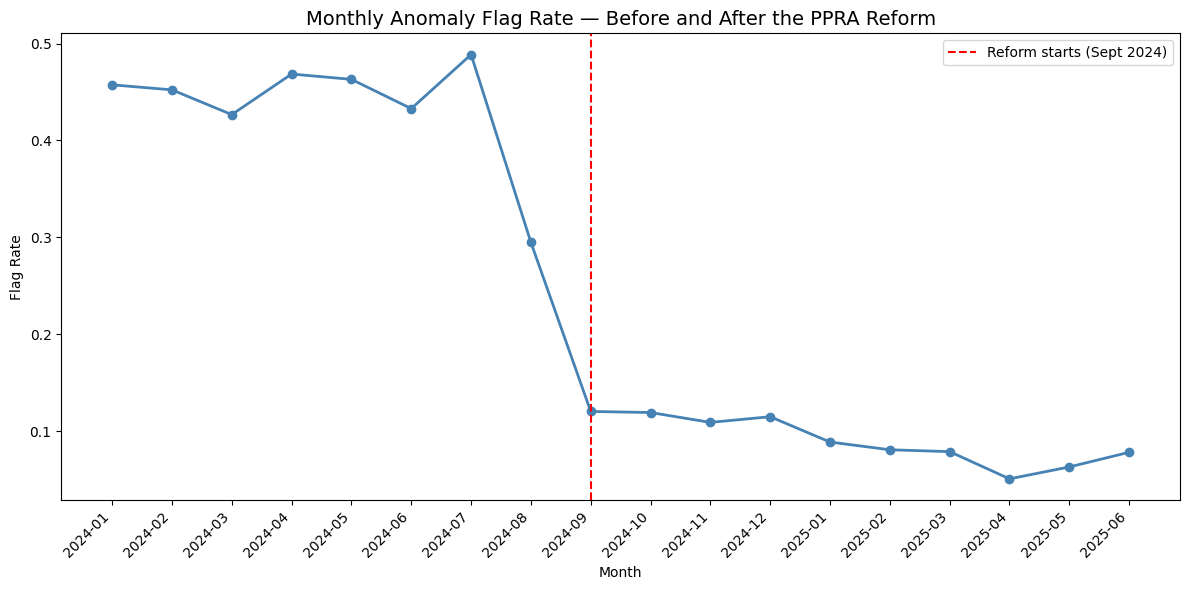

Chart saved as flag_rate_over_time.png


In [22]:
# ============================================
# STEP 16: Plot flag rate over time
# This lets us SEE if the reform caused a real break,
# or if it's just noise from a messy pre-period
# ============================================

import matplotlib.pyplot as plt

# turn year_month back into a plain string, easier for plotting
plot_data = model_data.copy()
plot_data["month_label"] = plot_data["id_year_month"].astype(str)

plt.figure(figsize=(12, 6))

# draw the actual flag rate, month by month
plt.plot(
    plot_data["month_label"],
    plot_data["flag_rate"],
    marker="o",
    color="steelblue",
    linewidth=2
)

# draw a vertical line right where the reform happened
# September 2024 is the 9th row (index 8) in our table
reform_index = plot_data[plot_data["id_year_month"] == pd.Period("2024-09", freq="M")].index[0]
plt.axvline(x=reform_index, color="red", linestyle="--", label="Reform starts (Sept 2024)")

plt.title("Monthly Anomaly Flag Rate — Before and After the PPRA Reform", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Flag Rate")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()

plt.savefig("flag_rate_over_time.png", dpi=150)
plt.show()

print("Chart saved as flag_rate_over_time.png")

In [23]:
# ============================================
# STEP 17: Separate the digitization effect (Aug 2024)
# from the levy effect (Sept 2024)
# ============================================

import statsmodels.api as sm

# start fresh from our clean monthly table
model_data2 = monthly_summary.copy()
model_data2 = model_data2.reset_index()

# switch 1: turns on starting August 2024 (digitization month)
digitization_start = pd.Period("2024-08", freq="M")
model_data2["after_digitization"] = (model_data2["id_year_month"] >= digitization_start).astype(int)

# switch 2: turns on starting September 2024 (levy month)
levy_start = pd.Period("2024-09", freq="M")
model_data2["after_levy"] = (model_data2["id_year_month"] >= levy_start).astype(int)

# keep the same general trend control as before
model_data2["month_number"] = range(len(model_data2))

# our outcome variable is still flag_rate
X = model_data2[["after_digitization", "after_levy", "month_number"]]
X = sm.add_constant(X)
y = model_data2["flag_rate"]

model2 = sm.OLS(y, X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:              flag_rate   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     445.6
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           4.02e-14
Time:                        11:49:34   Log-Likelihood:                 46.811
No. Observations:                  18   AIC:                            -85.62
Df Residuals:                      14   BIC:                            -82.06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.4692      0

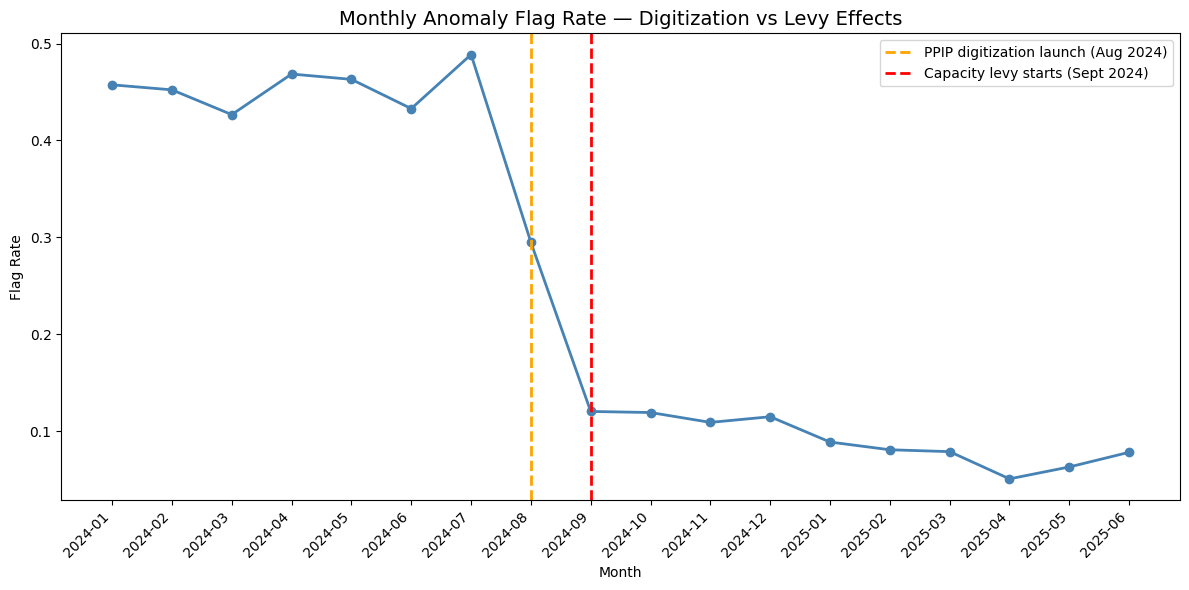

Chart saved as flag_rate_two_effects.png


In [24]:
# ============================================
# STEP 18: Plot flag rate with BOTH reform points marked
# One line for the digitization launch (Aug 2024)
# One line for the levy start (Sept 2024)
# ============================================

import matplotlib.pyplot as plt

# turn year_month back into plain text, easier to put on a chart
plot_data = model_data2.copy()
plot_data["month_label"] = plot_data["id_year_month"].astype(str)

plt.figure(figsize=(12, 6))

# draw the actual flag rate, one dot per month, connected by a line
plt.plot(
    plot_data["month_label"],
    plot_data["flag_rate"],
    marker="o",
    color="steelblue",
    linewidth=2
)

# find where August 2024 sits in our table, so we can draw a line there
digitization_index = plot_data[
    plot_data["id_year_month"] == pd.Period("2024-08", freq="M")
].index[0]

# find where September 2024 sits, for the second line
levy_index = plot_data[
    plot_data["id_year_month"] == pd.Period("2024-09", freq="M")
].index[0]

# draw the digitization line first (orange, dashed)
plt.axvline(
    x=digitization_index,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="PPIP digitization launch (Aug 2024)"
)

# draw the levy line second (red, dashed)
plt.axvline(
    x=levy_index,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Capacity levy starts (Sept 2024)"
)

plt.title("Monthly Anomaly Flag Rate — Digitization vs Levy Effects", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Flag Rate")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()

# save it so you have a file ready to drop into the paper
plt.savefig("flag_rate_two_effects.png", dpi=150)
plt.show()

print("Chart saved as flag_rate_two_effects.png")